**Objective**: Perform a comprehensive statistical analysis of the Multinomial Distribution. Derive the MLEs for the probabilities $(p_k)$ of the multinomial distribution. Run a Monte Carlo simulation to generate data, estimate MLEs, and plot the distribution of these estimated parameters. Calculate both the theoretical asymptotic variance and the empirical variance of the estimated parameters.

#### Multinomial Distribution and PMF

This is a generalization of the Binomial Distribution. While the Binomial Distribution models the number of successes in a fixed number of independent Bernoulli trials, where each trial has only two possible outcomes (success or failure), the Multinomial Distribution models the number of outcomes for *each* of several categories in a fixed number of independent trials. In essence, it describes the probabilities of observing a certain count for each of $K$ possible outcomes when $n$ independent trials are performed, and each trial results in exactly one of the $K$ outcomes.

The Multinomial Distribution is used to answer questions like: "What is the probability of observing $x1$ outcomes of category 1, $x2$ outcomes of category 2, ..., and $xK$ outcomes of category $K$ in $n$ trials?

Typical scenarios where the Multinomial Distribution is applicable include
*   **Survey responses** where respondents choose one option from several predefined categories, the multinomial distribution can model the probability of observing a certain number of responses for each category.
*   **Genetic studies** predicting the number of offspring with different genotypes from a cross.
*   **Analyzing text data**, counting the frequency of different words in a document (Bag-of-Words model).

The Multinomial Distribution is defined by parameters:
1.  **Number of trials ($n$)** of independent trials or observations. Each trial results in one of the $K$ possible outcomes.
2.  **Number of categories ($K$)** represents the total number of distinct possible outcomes for each trial. $K$ must be an integer greater than or equal to 2.
3.  **Probabilities for each category ($p_1, p_2, ..., p_K$)** are the probabilities of observing each specific outcome in a single trial. For each category $k$, $p_k$ is the probability that a single trial will result in outcome $k$, with the essential condition that the sum of these probabilities equals 1: $p_1 + p_2 + ... + p_K = 1$.
4.  **Counts for each category ($x_1, x_2, ..., x_K$)** are the observed number of times each category $k$ occurred over $n$ trials. The sum of these counts equals the total number of trials: $x_1 + x_2 + ... + x_K = n$.


The PMF of the Multinomial Distribution gives the probability of observing a specific set of counts $(x_1, x_2, ..., x_K)$ for $K$ categories in $n$ trials, given the probabilities $(p_1, p_2, ..., p_K)$ for each category.

The PMF is given by
- $P(X_1=x_1, X_2=x_2, \dots, X_K=x_K) = \frac{n!}{x_1!x_2!\dots x_K!} p_1^{x_1} p_2^{x_2} \dots p_K^{x_K}$

Where:
*   $n$: The total number of trials.
*   $K$: The number of possible categories or outcomes.
*   $x_i$: The number of times outcome $i$ occurs, for $i = 1, 2, ..., K$. It must satisfy $\sum_{i=1}^{K} x_i = n$.
*   $p_i$: The probability of outcome $i$ occurring in a single trial, for $i = 1, 2, ..., K$. It must satisfy $\sum_{i=1}^{K} p_i = 1$ and $0 \le p_i \le 1$.
*   $n!$: The factorial of $n$ $(n * (n-1) * ... * 1)$.
*   $x_i!$: The factorial of $x_i$.

The term $\frac{n!}{x_1!x_2!\dots x_K!}$ is the multinomial coefficient, representing the number of ways to partition $n$ items into $K$ distinct groups with sizes $x_1, x_2, ..., x_K$.


#### Derivation of MLEs for Multinomial Probabilities

**Likelihood Function**

The PMF for a single observation in the multinomial distribution is given by
- $P(n_1, n_2, \ldots, n_M; p_1, p_2, \ldots, p_M) = \frac{N!}{n_1!n_2!\ldots n_M!} p_1^{n_1} p_2^{n_2} \ldots p_M^{n_M}$

Deriving MLEs, we treat the observed counts $n_k$ as fixed and the probabilities $p_k$ as the parameters we want to estimate. Thus, the likelihood function $L$ for the multinomial distribution is defined as
- $L(p_1, p_2, \ldots, p_M | n_1, n_2, \ldots, n_M) = \frac{N!}{n_1!n_2!\ldots n_M!} \prod_{k=1}^M p_k^{n_k}$

Here, the term $\frac{N!}{n_1!n_2!\ldots n_M!}$ is a constant with respect to $p_k$, and does not affect the maximization process. We effectively ignore it for the purpose of finding the MLEs, as maximizing $L$ is equivalent to maximizing the part that depends on $p_k$.
- $L(p_1, p_2, \ldots, p_M | n_1, n_2, \ldots, n_M) \propto \prod_{k=1}^M p_k^{n_k}$

**Log-Likelihood Function**

Taking the logarithm converts products into sums, which are easier to differentiate. The log-likelihood function is
- $l(p_1, p_2, \ldots, p_M | n_1, n_2, \ldots, n_M) = \ln\left(\prod_{k=1}^M p_k^{n_k}\right)$

Using the logarithm property $\ln(ab) = \ln(a) + \ln(b)$ and $\ln(a^b) = b \ln(a)$
- $l(p_1, p_2, \ldots, p_M | n_1, n_2, \ldots, n_M) = \sum_{k=1}^M n_k \ln(p_k)$$

**Lagrange Multiplier for Constraint**

Maximizing the log-likelihood function, we consider the constraint that the sum of the probabilities equals 1. That is, $\sum_{k=1}^M p_k = 1$. Without this constraint, we could make any $p_k$ arbitrarily large to maximize the log-likelihood, which would violate the definition of probabilities.

To incorporate this constraint into our maximization problem, we use the method of Lagrange multipliers. The constraint can be written as $\sum_{k=1}^M p_k - 1 = 0$

We introduce a Lagrange multiplier, $\lambda$, to account for this equality constraint. The next step will involve formulating the Lagrangian function using this multiplier.

**Step 4: Formulate the Lagrangian Function**

Now, we combine the log-likelihood function and the constraint using the Lagrange multiplier to form the Lagrangian function, $L_G$.
- $L_G(p_1, \ldots, p_M, \lambda) = l(p_1, \ldots, p_M) + \lambda \left(1 - \sum_{k=1}^M p_k\right)$

Substituting the expression for the log-likelihood function from Step 2:
- $L_G(p_1, \ldots, p_M, \lambda) = \sum_{k=1}^M n_k \ln(p_k) + \lambda \left(1 - \sum_{k=1}^M p_k\right)$

Our goal is to find the values of $p_k$ and $\lambda$ that maximize this Lagrangian function. This is achieved by taking partial derivatives with respect to each $p_k$ and with respect to $\lambda$, and setting them to zero.

**Compute Partial Derivatives**

To find MLEs, we find the values of $p_k$ and $\lambda$ that set the partial derivatives of the Lagrangian function to zero. We differentiate $L_G$ with respect to each $p_k$ and with respect to $\lambda$.

Given the Lagrangian function:
- $L_G(p_1, \ldots, p_M, \lambda) = \sum_{k=1}^M n_k \ln(p_k) + \lambda \left(1 - \sum_{k=1}^M p_k\right)$

**1. Partial derivative with respect to $p_j$ (for any $j \in \{1, \ldots, M\}$):**
- $\frac{\partial L_G}{\partial p_j} = \frac{\partial}{\partial p_j} \left( n_j \ln(p_j) + \lambda (1 - p_j) \right)$$

(Note: All other terms $n_k \ln(p_k)$ where $k \ne j$ are treated as constants, and $\sum_{k=1}^M p_k$ becomes just $p_j$ for the derivative with respect to $p_j$ within the sum.)
- $\frac{\partial L_G}{\partial p_j} = \frac{n_j}{p_j} - \lambda$

**2. Partial derivative with respect to $\lambda$:**
- $\frac{\partial L_G}{\partial \lambda} = \frac{\partial}{\partial \lambda} \left( \sum_{k=1}^M n_k \ln(p_k) + \lambda \left(1 - \sum_{k=1}^M p_k\right) \right)$
- $\frac{\partial L_G}{\partial \lambda} = 1 - \sum_{k=1}^M p_k$

**Solve for MLEs**

Set the partial derivatives equal to zero and solve for $p_j$ and $\lambda$.

From $\frac{\partial L_G}{\partial p_j} = 0$, $\frac{n_j}{p_j} - \lambda = 0 = \lambda$, $p_j = \frac{n_j}{\lambda}$ (Equation 1)

This equation tells us that each $p_j$ is proportional to its corresponding count $n_j$, with $\lambda$ being the constant of proportionality. From $\frac{\partial L_G}{\partial \lambda} = 0$, $1 - \sum_{k=1}^M p_k = 0$ ; $\sum_{k=1}^M p_k = 1$ (Equation 2)

This is simply our original constraint that the probabilities must sum to 1. With the substitutions  $\sum_{k=1}^M \frac{n_k}{\lambda} = 1$. We factor out $\frac{1}{\lambda}$ from the sum $\frac{1}{\lambda} \sum_{k=1}^M n_k = 1$. The sum of all counts $\sum_{k=1}^M n_k$ is equal to the total number of trials $N$. Therefore, $\frac{1}{\lambda} N = 1$

Solving for $\lambda$, $\lambda = N$, we  find the MLE for each
- $p_j$:  $p_j = \frac{n_j}{N}$

Thus, the MLE for the probability $p_j$ of category $j$ in a multinomial distribution is the observed frequency of that category, i.e., the number of times category $j$ occurred ($n_j$) divided by the total number of trials ($N$).


**Plot the Distribution of Estimated Parameters**

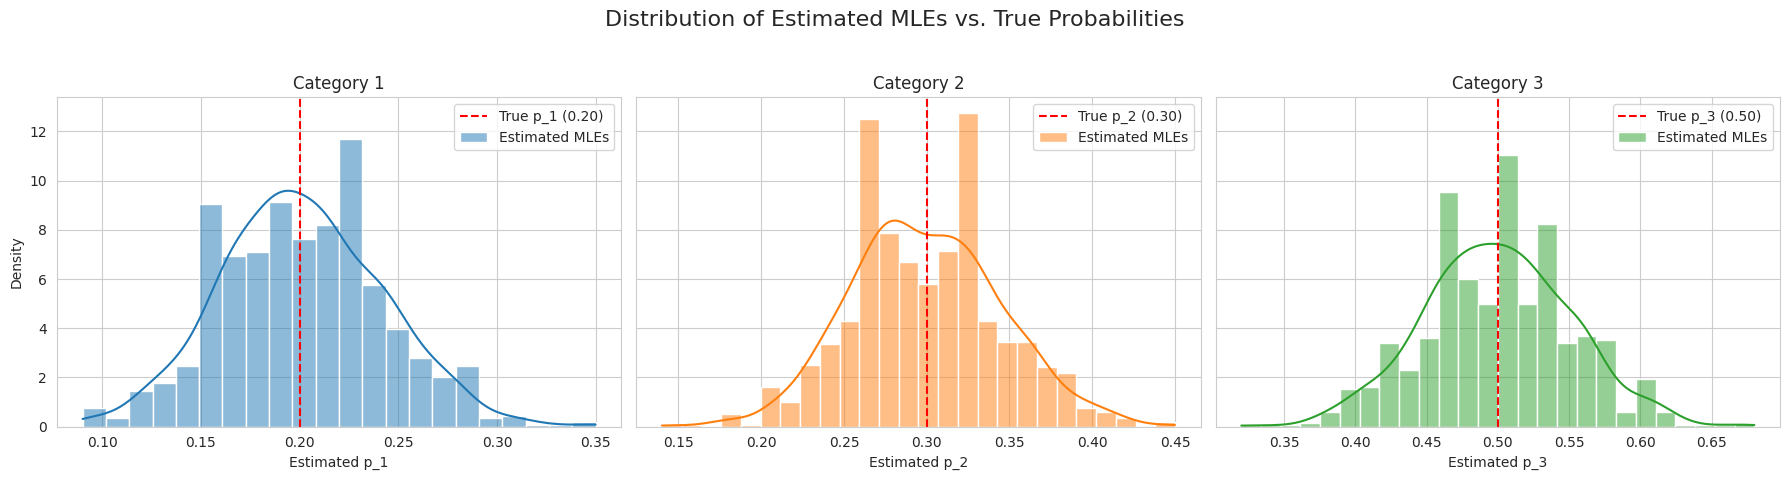

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Create subplots for each category
fig, axes = plt.subplots(1, K, figsize=(6 * K, 5), sharey=True)
fig.suptitle('Distribution of Estimated MLEs vs. True Probabilities', fontsize=16)

for i in range(K):
    # Extract the estimated MLEs for the current category
    mles_for_category = estimated_mles[:, i]

    # Plot histogram and KDE
    sns.histplot(mles_for_category, kde=True, ax=axes[i], color=f'C{i}', stat='density', label='Estimated MLEs')

    # Overlay the true probability as a vertical line
    axes[i].axvline(p_true[i], color='red', linestyle='--', label=f'True p_{i+1} ({p_true[i]:.2f})')

    # Add labels and title
    axes[i].set_title(f'Category {i+1}')
    axes[i].set_xlabel(f'Estimated p_{i+1}')
    if i == 0:
        axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

#### Performance of MLEs

*   **Accuracy**: The Monte Carlo simulation demonstrates that the MLEs ($\hat{p}_k$) for the multinomial probabilities are effective in estimating the true probabilities ($p_k$). As observed in the plotting, the peaks of the distributions of the estimated MLEs for each category align closely with their respective true probabilities. This suggests that the MLEs are unbiased or at least asymptotically unbiased, clustering around the true values.

*   **Distribution**: The distributions of the estimated MLEs for each $p_k$ (as shown by the histograms and KDE plots) are approximately bell-shaped, indicating that as the number of simulations increases, the sampling distribution of the MLEs tends towards a normal distribution, consistent with the Central Limit Theorem for estimators.


#### Empirical Variance and Comparison

The **empirical variance** for each estimated parameter $\hat{p}_k$ is calculated directly from the num_simulations (1000 in this case) of the Monte Carlo simulation. For each category, we collect all the $\hat{p}_k$ values estimated across the simulations and then compute their variance. This reflects the observed variability of our estimator in practice.

Comparison with Theoretical Asymptotic Variance

As derived and calculated previously, the theoretical asymptotic variance for $\hat{p}_k$ in a multinomial distribution is given by $\text{Var}(\hat{p}_k) = \frac{p_k(1-p_k)}{n}$. This theoretical value represents the expected variance of the MLE under large sample conditions.

The comparison between the empirical variances obtained from our Monte Carlo simulation and these theoretical values is shown in the plot, which indicates a close agreement between the simulated outcomes and theoretical predictions.

#### Agreement Between Empirical and Theoretical Variances:

*   **Close Correspondence**: The comparison table shows a close agreement between the empirical variances (calculated from the simulated MLEs) and the theoretical asymptotic variances (derived from the formula $\text{Var}(\hat{p}_k) = p_k(1-p_k)/n$). The absolute differences between these values are very small, in the order of $10^{-5}$ to $10^{-4}$.
*   **Implication**: This strong agreement validates both the theoretical derivation of the asymptotic variance and the accuracy of the Monte Carlo simulation. It confirms that for a sufficiently large number of trials ($n$) and simulations (num_simulations), the empirical behavior of the MLEs, particularly their variability, closely matches theoretical predictions.

The Monte Carlo simulation effectively illustrates the properties of MLEs for the multinomial distribution, accurately estimating the true probabilities, and their sampling distributions are well-approximated by theoretical predictions, especially regarding their variances. This provides confidence in using MLEs for parameter estimation in multinomial settings, particularly with large sample sizes.

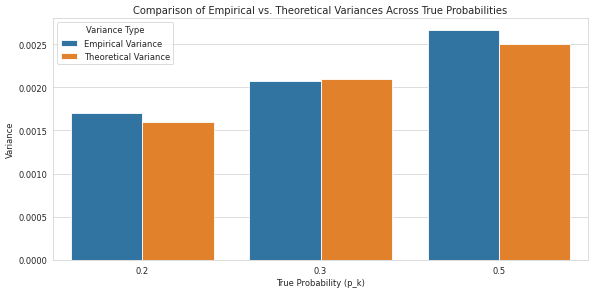

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define true probabilities for each category (p_true)
p_true = np.array([0.2, 0.3, 0.5]) # Ensure these sum to 1

# Define the number of categories (K)
K = len(p_true)

# Define the number of trials for each experiment (n)
n = 100

# Define the total number of Monte Carlo simulations to run
num_simulations = 1000

# Initialize an empty list to store the estimated MLEs
estimated_mles_list = []

# Loop num_simulations times
for _ in range(num_simulations):
    # a. Generate data from a multinomial distribution
    # The result `counts` will be an array of K integers, where sum(counts) == n
    counts = np.random.multinomial(n, p_true, size=1)[0]

    # b. Calculate the Maximum Likelihood Estimators (MLEs)
    # MLE for p_k is n_k / N, where n_k is the count for category k and N is total trials
    p_mle = counts / n

    # c. Store these estimated MLEs
    estimated_mles_list.append(p_mle)

# Convert the list of estimated MLEs into a NumPy array
estimated_mles = np.array(estimated_mles_list)

# Calculate Empirical Variances
# The empirical variance is the variance of the estimated_mles for each category
empirical_variances = np.var(estimated_mles, axis=0)

# Calculate Theoretical Asymptotic Variances
# For a multinomial distribution, the asymptotic variance of the MLE for p_k
# is given by Var(p_k_hat) = p_k * (1 - p_k) / n
theoretical_variances = np.array([p_true[i] * (1 - p_true[i]) / n for i in range(K)])

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'True Probability': p_true,
    'Empirical Variance': empirical_variances,
    'Theoretical Variance': theoretical_variances,
    'Absolute Difference': np.abs(empirical_variances - theoretical_variances)
})

sns.set_style("whitegrid")

# Prepare data for plotting
plot_df = comparison_df.melt(id_vars=['True Probability'], value_vars=['Empirical Variance', 'Theoretical Variance'], var_name='Variance Type', value_name='Variance Value')

plt.figure(figsize=(10, 5), dpi=60)
sns.barplot(x='True Probability', y='Variance Value', hue='Variance Type', data=plot_df)
plt.title('Comparison of Empirical vs. Theoretical Variances Across True Probabilities')
plt.xlabel('True Probability (p_k)') ; plt.ylabel('Variance')
plt.legend(title='Variance Type') ; plt.tight_layout() ; plt.show()

**Concept of Asymptotic Variance for MLEs**

The asymptotic variance of a MLE describes the variance of the estimator as the sample size approaches infinity. For many well-behaved statistical models, including the multinomial distribution, MLEs possess desirable asymptotic properties

1.  **Consistency**: As the sample size increases, the MLE converges in probability to the true parameter value.
2.  **Asymptotic Normality**: As the sample size increases, the sampling distribution of the MLE approaches a normal distribution.
3.  **Efficiency**: MLEs are asymptotically efficient, meaning they achieve the Cramér-Rao lower bound, which is the lowest possible variance for an unbiased estimator. The inverse of the Fisher Information gives this lower bound.

In the context of the multinomial distribution, the MLE for each probability $p_k$ is $\hat{p}_k = \frac{n_k}{N}$, where $n_k$ is the count for category $k$ and $N$ is the total number of trials. The asymptotic variance of this estimator for a given $p_k$ is a measure of how much the estimated $\hat{p}_k$ is expected to vary around the true $p_k$ when the number of trials $n$ is large. A smaller asymptotic variance indicates a more precise estimator.

For the multinomial distribution, the theoretical asymptotic variance of the MLE for each probability $p_k$ is given by $\text{Var}(\hat{p}_k) = \frac{p_k(1-p_k)}{n}$, where $p_k$: The true probability for category $k$; $n$: The total number of trials per experiment.

This is a direct result of the properties of the multinomial distribution and the Fisher Information for its parameters. It shows that the variance decreases as the number of trials ($n$) increases, which is intuitive: more data generally leads to more precise estimates.